In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("../data/MEC_KEAM_Cutoff_Consolidated.xlsx")

df.head()

,Year,Course,Admission Category,Last Rank
0,2023,Computer Science & Engineering,MG,2460.0
1,2023,Computer Science & Engineering,SM,1035.0
2,2023,Computer Science & Engineering,EZ,3459.0
3,2023,Computer Science & Engineering,MU,1759.0
4,2023,Computer Science & Engineering,EW,8612.0


In [4]:
df.shape

(294, 4)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                294 non-null    int64  
 1   Course              294 non-null    str    
 2   Admission Category  294 non-null    str    
 3   Last Rank           227 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 9.3 KB


In [6]:
df.columns

Index(['Year', 'Course', 'Admission Category', 'Last Rank'], dtype='str')

In [7]:
df.isnull().sum()

Year                   0
Course                 0
Admission Category     0
Last Rank             67
dtype: int64

In [8]:
df["Year"].unique()

array([2023, 2024, 2025])

In [9]:
df["Year"].value_counts()

Year
2023    98
2024    98
2025    98
Name: count, dtype: int64

In [10]:
df["Admission Category"].value_counts()

Admission Category
MG    21
SM    21
EZ    21
MU    21
EW    21
SC    21
BH    21
VK    21
LA    21
DV    21
BX    21
KU    21
KN    21
ST    21
Name: count, dtype: int64

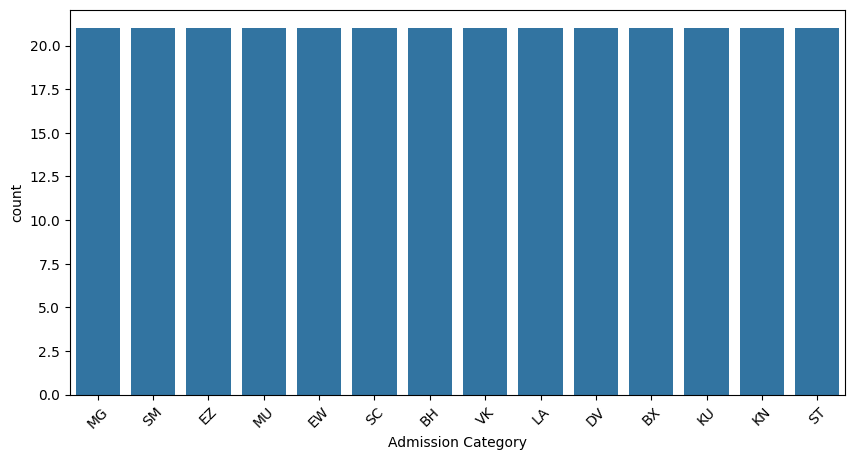

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Admission Category")
plt.xticks(rotation=45)
plt.show()

In [12]:
df["Course"].value_counts()

Course
Computer Science & Engineering           42
Computer Science and Business Systems    42
Electronics & Biomedical Engg            42
Electronics & Communication              42
Electrical & Electronics                 42
Electronics Engineering (VLSI Design)    42
Mechanical Engineering                   42
Name: count, dtype: int64

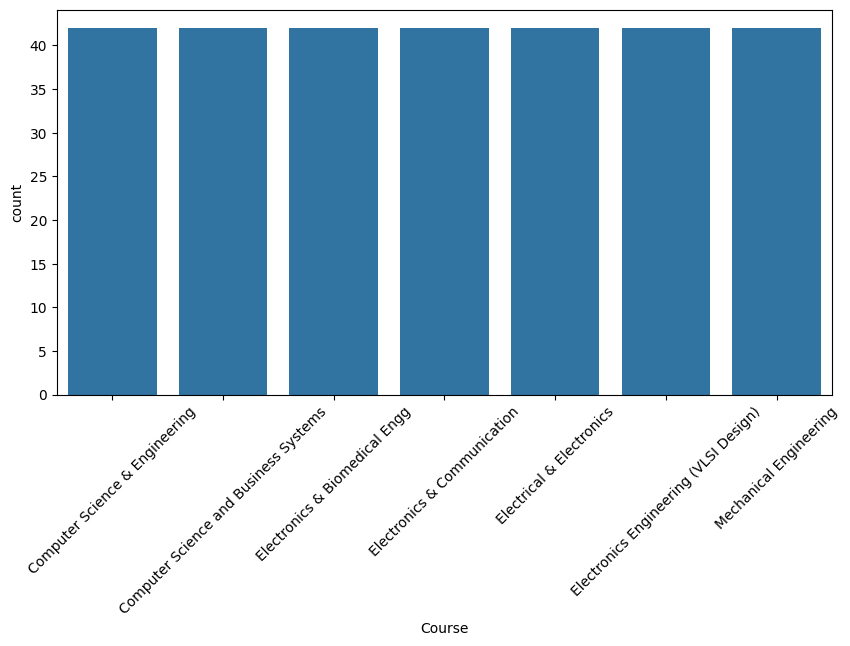

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Course")
plt.xticks(rotation=45)
plt.show()

In [14]:
df["Last Rank"].describe()

count      227.000000
mean     12930.224670
std      11536.270348
min       1035.000000
25%       4601.000000
50%       8960.000000
75%      16712.500000
max      53777.000000
Name: Last Rank, dtype: float64

In [15]:
print("Skewness:",df["Last Rank"].skew())

Skewness: 1.4631344823863326


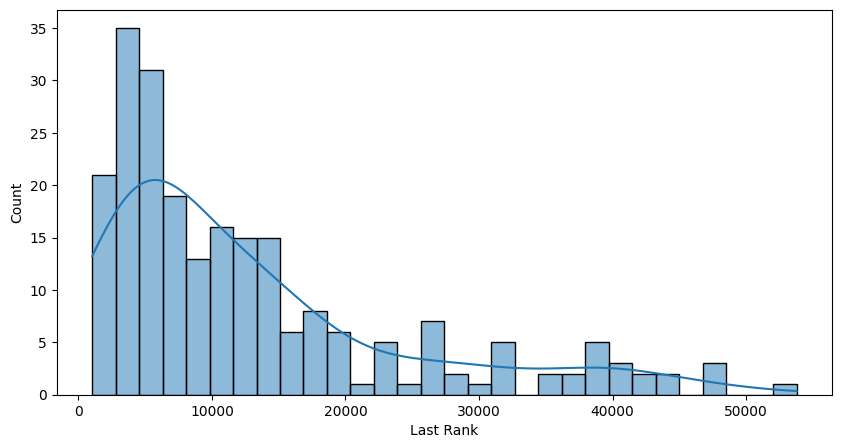

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df["Last Rank"],bins=30,kde=True)
plt.show()

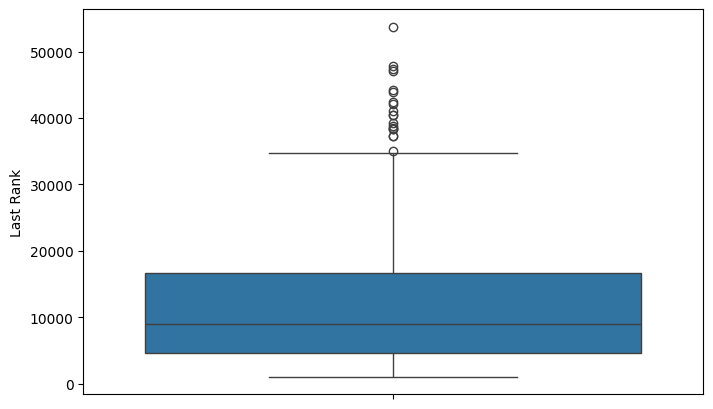

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Last Rank"])
plt.show()

In [18]:
course_avg = df.groupby("Course")["Last Rank"].mean().sort_values()

print(course_avg)

Course
Computer Science & Engineering            7325.928571
Electronics & Communication               8555.135135
Computer Science and Business Systems    10644.645161
Electrical & Electronics                 11576.366667
Electronics Engineering (VLSI Design)    16375.896552
Electronics & Biomedical Engg            19535.750000
Mechanical Engineering                   20391.833333
Name: Last Rank, dtype: float64


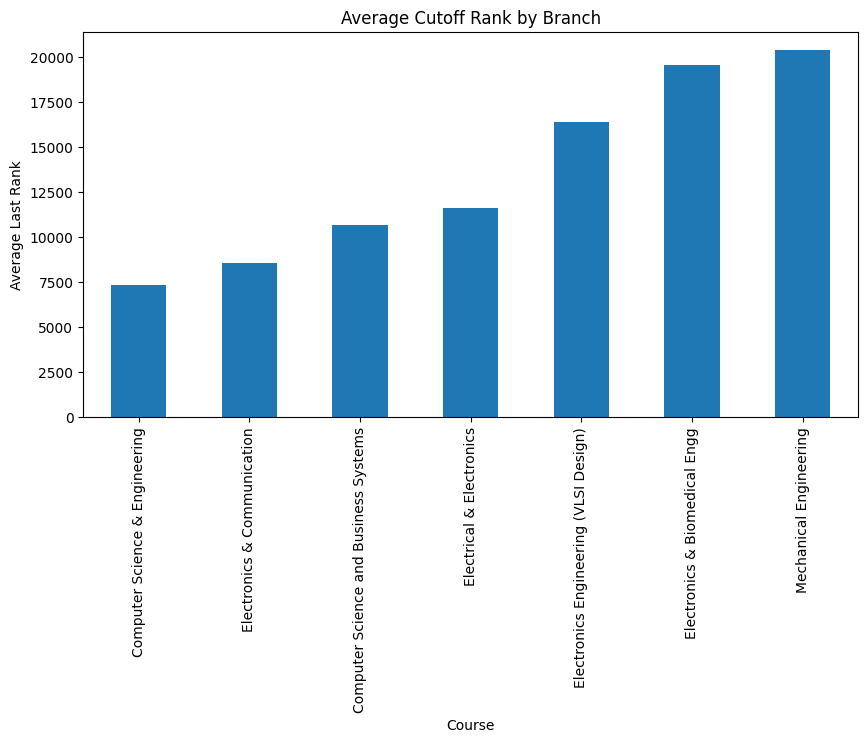

In [19]:
plt.figure(figsize=(10,5))
course_avg.plot(kind="bar")
plt.ylabel("Average Last Rank")
plt.title("Average Cutoff Rank by Branch")
plt.show()

In [20]:
course_avg.sort_values()

Course
Computer Science & Engineering            7325.928571
Electronics & Communication               8555.135135
Computer Science and Business Systems    10644.645161
Electrical & Electronics                 11576.366667
Electronics Engineering (VLSI Design)    16375.896552
Electronics & Biomedical Engg            19535.750000
Mechanical Engineering                   20391.833333
Name: Last Rank, dtype: float64

In [21]:
year_course = df.pivot_table(
    values="Last Rank",
    index="Year",
    columns="Course",
    aggfunc="mean"
)

year_course

Course,Computer Science & Engineering,Computer Science and Business Systems,Electrical & Electronics,Electronics & Biomedical Engg,Electronics & Communication,Electronics Engineering (VLSI Design),Mechanical Engineering
Year,,,,,,,
2023,6954.214286,13121.545455,13253.3,20837.5,6803.800000,18213.100000,21284.0
2024,7518.857143,10200.400000,9642.0,17448.0,11913.571429,16009.700000,19250.9
2025,7504.714286,8364.300000,11833.8,20582.1,6285.538462,14741.444444,20640.6


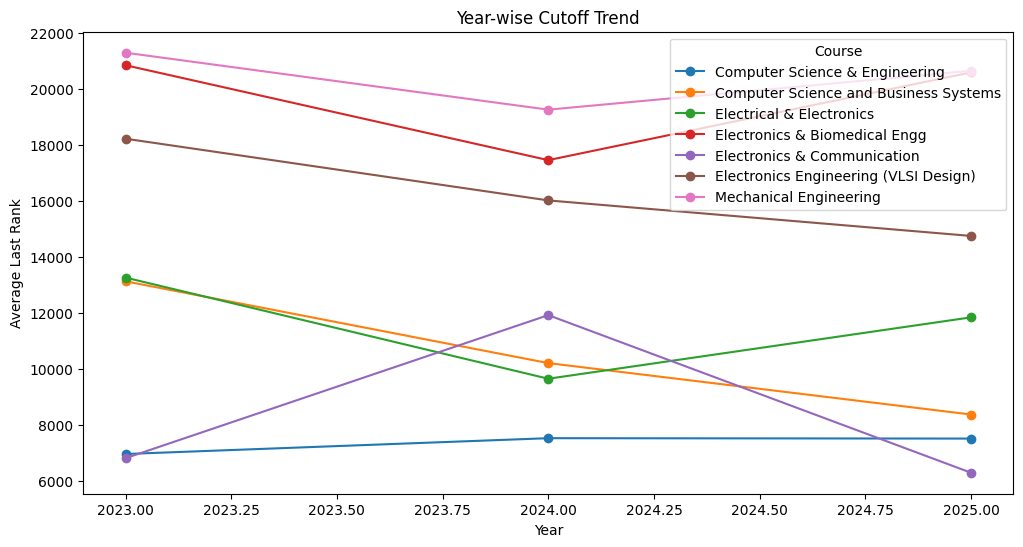

In [22]:
year_course.plot(
    figsize=(12,6),
    marker="o"
)

plt.ylabel("Average Last Rank")
plt.title("Year-wise Cutoff Trend")
plt.show()

In [23]:
category_avg = df.groupby(
    "Admission Category"
)["Last Rank"].mean().sort_values()

category_avg

Admission Category
SM     5962.047619
MU     7646.476190
EZ     8406.809524
LA     9239.333333
VK    10104.500000
MG    10615.666667
EW    10922.400000
BH    12188.000000
BX    12470.750000
KU    13594.818182
DV    14137.368421
KN    14634.166667
SC    32936.533333
ST    36550.400000
Name: Last Rank, dtype: float64

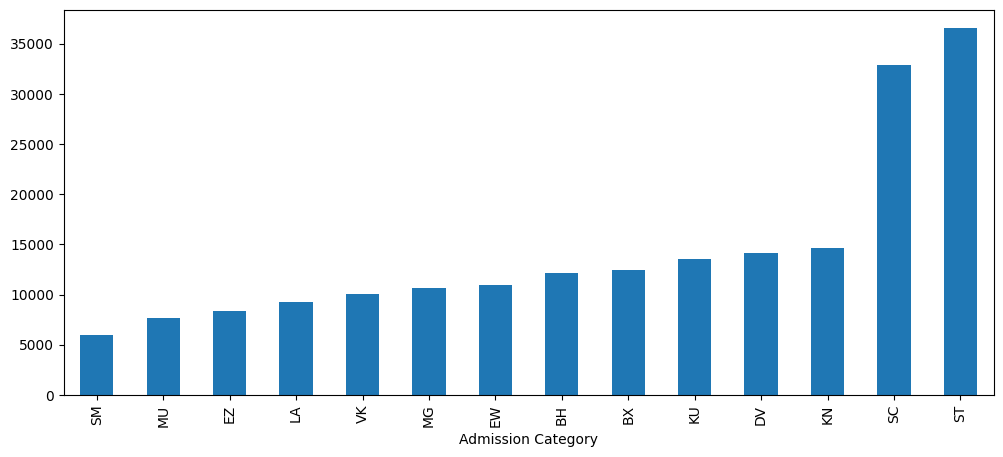

In [24]:
plt.figure(figsize=(12,5))
category_avg.plot(kind="bar")
plt.show()

In [25]:
pivot = df.pivot_table(
    values="Last Rank",
    index="Admission Category",
    columns="Course",
    aggfunc="mean"
)

pivot

Course,Computer Science & Engineering,Computer Science and Business Systems,Electrical & Electronics,Electronics & Biomedical Engg,Electronics & Communication,Electronics Engineering (VLSI Design),Mechanical Engineering
Admission Category,,,,,,,
BH,14906.333333,17227.000000,5715.000000,13685.500000,3688.000000,9463.500000,16752.000000
BX,3450.000000,8413.000000,13815.000000,24752.000000,12043.666667,11429.000000,20007.000000
DV,3753.666667,10253.333333,10560.666667,24044.500000,6137.000000,25746.500000,25638.000000
EW,4917.666667,6723.500000,11537.000000,18849.500000,4882.500000,13784.000000,18765.000000
EZ,2679.666667,5704.000000,7482.333333,14635.000000,4511.333333,9671.666667,14163.666667
KN,4253.000000,NaN,NaN,NaN,20014.500000,35017.000000,NaN
KU,5998.666667,14910.000000,5763.000000,42419.000000,7583.000000,30726.000000,14980.000000
LA,2868.666667,4905.333333,9104.666667,15804.333333,4568.666667,9094.333333,18329.333333
MG,2757.666667,5371.666667,9092.333333,18648.000000,4611.333333,14321.000000,19507.666667


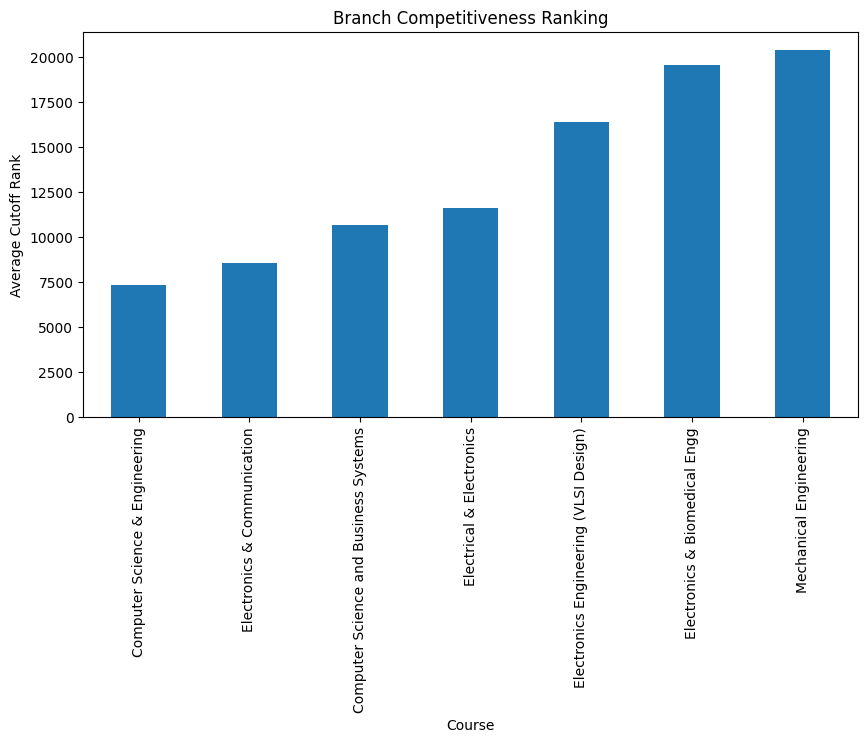

In [31]:
course_avg = df.groupby("Course")["Last Rank"].mean()

course_avg = course_avg.sort_values()

plt.figure(figsize=(10,5))

course_avg.plot(kind='bar')

plt.title("Branch Competitiveness Ranking")
plt.ylabel("Average Cutoff Rank")

plt.show()

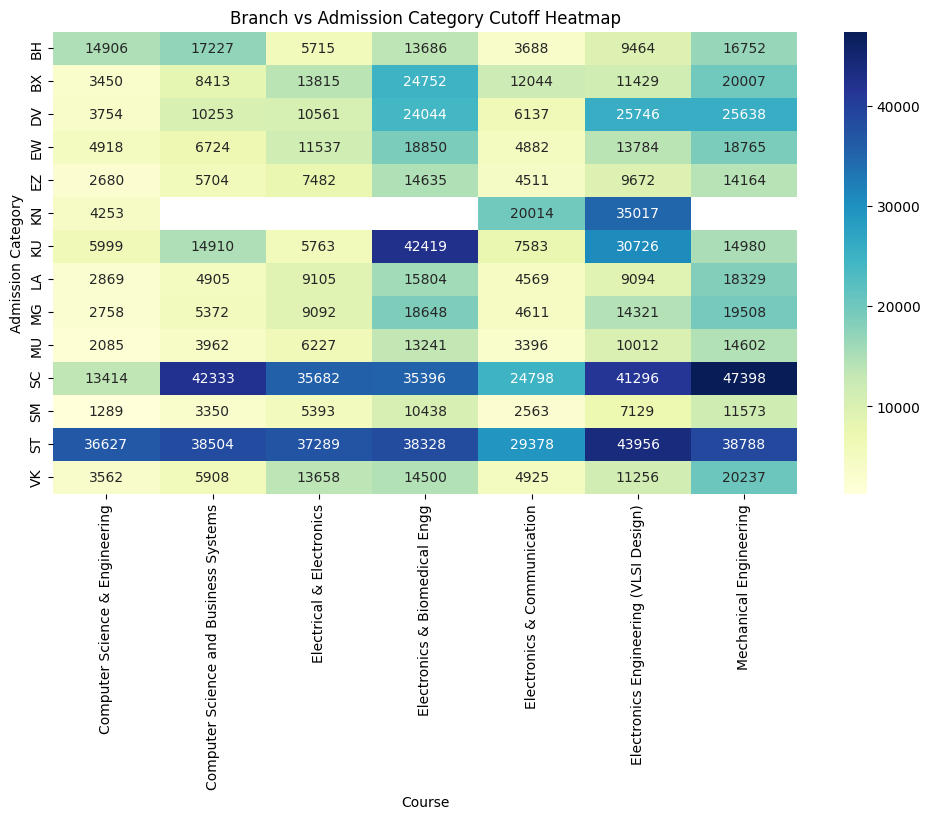

In [26]:
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Branch vs Admission Category Cutoff Heatmap")
plt.show()

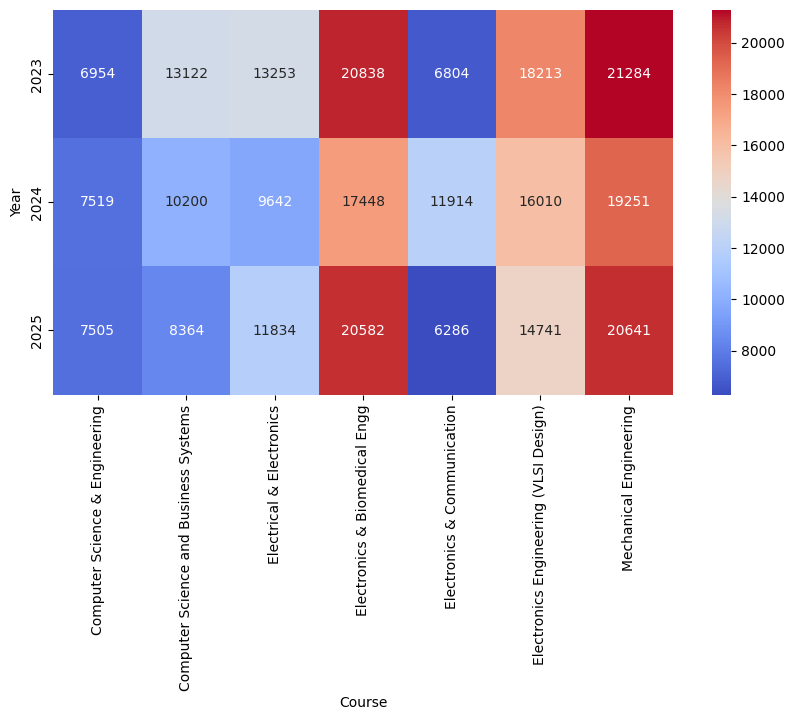

In [28]:
pivot2 = df.pivot_table(
    values="Last Rank",
    index="Year",
    columns="Course",
    aggfunc="mean"
)
plt.figure(figsize=(10,5))

sns.heatmap(
    pivot2,
    annot=True,
    fmt=".0f",
    cmap="coolwarm"
)

plt.show()

In [29]:
df.sort_values(
    by="Last Rank",
    ascending=False
).head(10)

,Year,Course,Admission Category,Last Rank
285,2025,Mechanical Engineering,SC,53777.0
111,2024,Computer Science & Engineering,ST,47902.0
117,2024,Computer Science and Business Systems,SC,47395.0
209,2025,Computer Science & Engineering,ST,47022.0
271,2025,Electronics Engineering (VLSI Design),SC,44291.0
83,2023,Electronics Engineering (VLSI Design),ST,43956.0
235,2025,Electronics & Biomedical Engg,KU,42419.0
20,2023,Computer Science and Business Systems,BH,42073.0
187,2024,Mechanical Engineering,SC,41019.0
6,2023,Computer Science & Engineering,BH,40517.0


In [30]:
df.sort_values(
    by="Last Rank",
    ascending=True
).head(10)

,Year,Course,Admission Category,Last Rank
1,2023,Computer Science & Engineering,SM,1035.0
99,2024,Computer Science & Engineering,SM,1286.0
197,2025,Computer Science & Engineering,SM,1546.0
9,2023,Computer Science & Engineering,DV,1562.0
3,2023,Computer Science & Engineering,MU,1759.0
8,2023,Computer Science & Engineering,LA,1772.0
11,2023,Computer Science & Engineering,KU,1825.0
101,2024,Computer Science & Engineering,MU,1981.0
100,2024,Computer Science & Engineering,EZ,2016.0
202,2025,Computer Science & Engineering,BH,2054.0


Course  Computer Science & Engineering  Computer Science and Business Systems  \
Year                                                                            
2023                       6954.214286                           13121.545455   
2024                       7518.857143                           10200.400000   
2025                       7504.714286                            8364.300000   

Course  Electrical & Electronics  Electronics & Biomedical Engg  \
Year                                                              
2023                     13253.3                        20837.5   
2024                      9642.0                        17448.0   
2025                     11833.8                        20582.1   

Course  Electronics & Communication  Electronics Engineering (VLSI Design)  \
Year                                                                         
2023                    6803.800000                           18213.100000   
2024                   1

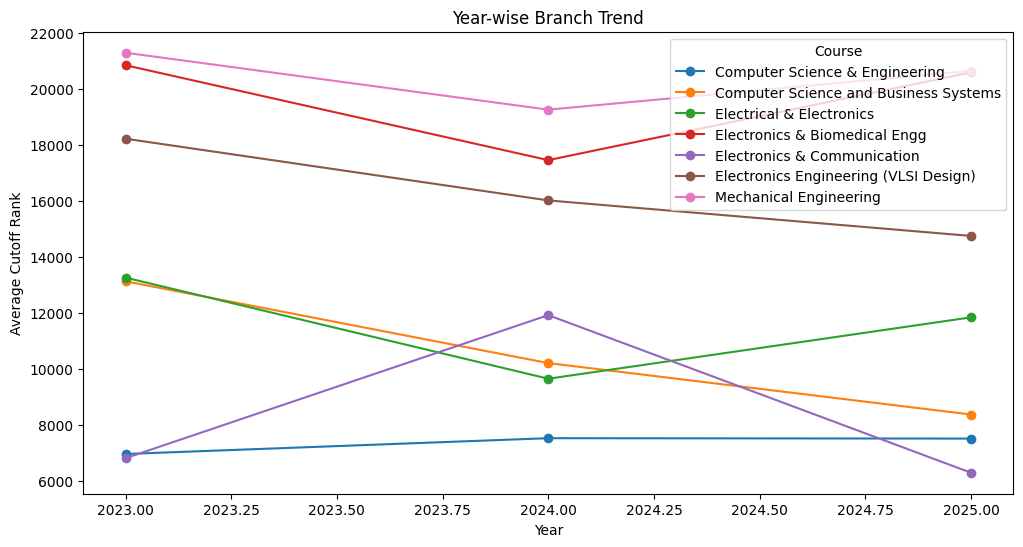

In [32]:
year_course = df.pivot_table(
    values='Last Rank',
    index='Year',
    columns='Course',
    aggfunc='mean'
)

print(year_course)
year_course.plot(marker='o', figsize=(12,6))
plt.ylabel("Average Cutoff Rank")
plt.title("Year-wise Branch Trend")
plt.show()

In [33]:
def analyze_chances(rank, admission_category):

    subset = df[
        df["Admission Category"] == admission_category
    ]

    result = {
        "Very High Chance": [],
        "High Chance": [],
        "Possible": [],
        "Low Chance": [],
        "Not Likely": []
    }

    for course in subset["Course"].unique():

        avg_cutoff = subset[
            subset["Course"] == course
        ]["Last Rank"].mean()

        if pd.isna(avg_cutoff):
            continue

        diff = avg_cutoff - rank

        if diff >= 3000:
            result["Very High Chance"].append(course)

        elif diff >= 1000:
            result["High Chance"].append(course)

        elif diff >= -500:
            result["Possible"].append(course)

        elif diff >= -3000:
            result["Low Chance"].append(course)

        else:
            result["Not Likely"].append(course)

    return result

In [34]:
analyze_chances(
    rank=3500,
    admission_category="SM"
)

{'Very High Chance': ['Electronics & Biomedical Engg',
  'Electronics Engineering (VLSI Design)',
  'Mechanical Engineering'],
 'High Chance': ['Electrical & Electronics'],
 'Possible': ['Computer Science and Business Systems'],
 'Low Chance': ['Computer Science & Engineering',
  'Electronics & Communication'],
 'Not Likely': []}

In [5]:
avg=df.groupby("Course")["Last Rank"].mean()

def competition(branch):

    cutoff=avg[branch]

    if cutoff<5000:
        return "Very High"

    elif cutoff<10000:
        return "High"

    elif cutoff<17000:
        return "Medium"

    else:
        return "Low"

df["Competition"] = df["Course"].apply(
    competition
)

df[["Course","Competition"]].head()

,Course,Competition
0,Computer Science & Engineering,High
1,Computer Science & Engineering,High
2,Computer Science & Engineering,High
3,Computer Science & Engineering,High
4,Computer Science & Engineering,High


In [7]:
def cutoff_level(rank):

    if pd.isna(rank):
        return "No Admission"

    elif rank<5000:
        return "Highly Competitive"

    elif rank<10000:
        return "Competitive"

    elif rank<20000:
        return "Moderate"

    else:
        return "Easy"

df["Cutoff Level"] = df["Last Rank"].apply(
    cutoff_level
)

df[
[
"Last Rank",
"Cutoff Level"
]
].head()

,Last Rank,Cutoff Level
0,2460.0,Highly Competitive
1,1035.0,Highly Competitive
2,3459.0,Highly Competitive
3,1759.0,Highly Competitive
4,8612.0,Competitive


In [8]:
df.head()

,Year,Course,Admission Category,Last Rank,Competition,Cutoff Level
0,2023,Computer Science & Engineering,MG,2460.0,High,Highly Competitive
1,2023,Computer Science & Engineering,SM,1035.0,High,Highly Competitive
2,2023,Computer Science & Engineering,EZ,3459.0,High,Highly Competitive
3,2023,Computer Science & Engineering,MU,1759.0,High,Highly Competitive
4,2023,Computer Science & Engineering,EW,8612.0,High,Competitive
